# Terrain Topography, Slope & Aspect — Devon

Demonstrates `eoflow.topography.get_topography_for_polygon`,
`eoflow.topography.get_slope_for_polygon`, and
`eoflow.topography.get_aspect_for_polygon` using real Devon data.

---

### Contents

1. Imports & configuration
2. Load Devon data
3. Elevation across Devon county
4. Interactive Devon elevation map
5. Slope analysis — Devon county
6. Aspect (slope direction) — Devon county  ← **new**
7. Per-catchment topography
8. Devon overview map — elevation + catchments
9. Dartmoor close-up: elevation, slope & aspect
10. Summary

---

**Data source:** [Copernicus DEM GLO-30](https://spacedata.copernicus.eu/collections/copernicus-digital-elevation-model)  
**Publisher:** European Space Agency / Copernicus Programme  
**Licence:** [Copernicus DEM Licence](https://doi.org/10.5270/ESA-c5d3d65)  
**Native CRS:** EPSG:4326 (WGS-84); reprojected to EPSG:27700 (British National Grid)  
**Resolution:** ~30 m native; resampled to 250 m for county-wide queries in this notebook  


## 0 — Imports & configuration

In [1]:
from __future__ import annotations

import io
import base64
import sys
import time as _time
import warnings
from pathlib import Path

import folium
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
import xarray as xr
from pyproj import Transformer

warnings.filterwarnings('ignore')

# ── Repo root ──────────────────────────────────────────────────────────────
try:
    REPO_ROOT = Path(__file__).resolve().parent.parent
except NameError:
    REPO_ROOT = Path.cwd().parent

if str(REPO_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / 'src'))

from eoflow.topography import (
    get_topography_for_polygon,
    get_slope_for_polygon,
    get_aspect_for_polygon,
)
from eoflow.samples import CatchmentDataset

DATA_DIR  = REPO_ROOT / 'data'
GPKG_PATH = REPO_ROOT / 'outputs' / 'ea_water_quality_devon_cop30_new.gpkg'
DEVON_SHP = DATA_DIR  / 'shapefiles' / 'devon_county' / 'devon_county.shp'
DEM_PATH  = DATA_DIR  / 'dems' / 'devon_dem_cop30.tif'

print('Repo root  :', REPO_ROOT)
print('GeoPackage :', GPKG_PATH, ' exists:', GPKG_PATH.exists())
print('Devon SHP  :', DEVON_SHP,  ' exists:', DEVON_SHP.exists())
print('DEM        :', DEM_PATH,   ' exists:', DEM_PATH.exists())


Repo root  : /home/finley/Work/RDS/projects/enforce/repos/eoflow
GeoPackage : /home/finley/Work/RDS/projects/enforce/repos/eoflow/outputs/ea_water_quality_devon_cop30_new.gpkg  exists: True
Devon SHP  : /home/finley/Work/RDS/projects/enforce/repos/eoflow/data/shapefiles/devon_county/devon_county.shp  exists: True
DEM        : /home/finley/Work/RDS/projects/enforce/repos/eoflow/data/dems/devon_dem_cop30.tif  exists: True


In [2]:
# ── Analysis parameters ────────────────────────────────────────────────────
RES_M         = 250          # 250 m output grid resolution for county-wide queries
RES_CATCHMENT = 50           # 50 m (default) for per-catchment queries

DEVON_CENTRE = [50.72, -3.8]
TILES        = 'CartoDB positron'
ELEV_CMAP    = 'terrain'
SLOPE_CMAP   = 'YlOrRd'
ASPECT_CMAP  = 'twilight'    # cyclic colourmap — ideal for 0-360° compass bearings

print(f'County resolution   : {RES_M} m  (increase for finer detail, decrease for speed)')
print(f'Catchment resolution: {RES_CATCHMENT} m')


County resolution   : 250 m  (increase for finer detail, decrease for speed)
Catchment resolution: 50 m


In [3]:
def _make_raster_overlay(
    da,
    cmap,
    vmin=None,
    vmax=None,
    alpha=0.70,
    label='Raster',
    percentile_clip=(2, 98),
):
    """
    Reproject a BNG DataArray to WGS-84 and encode as a folium ImageOverlay.

    BNG is a Transverse Mercator projection, so placing an un-warped BNG
    image inside a WGS-84 bounding box introduces a positional shift.
    This function corrects that by back-projecting every WGS-84 output
    pixel to BNG fractional array indices and interpolating.

    Parameters
    ----------
    da : xarray.DataArray
        2-D array with dims ('y', 'x') in EPSG:27700.  NaN = outside polygon.
    cmap : str
        Matplotlib colormap name.
    vmin, vmax : float or None
        Colour-scale limits.  If None, derived from *percentile_clip*.
    alpha : float
        Overlay opacity (0–1).
    label : str
        Layer name shown in the folium LayerControl.
    percentile_clip : (lo, hi)
        Percentile range used when *vmin*/*vmax* are not supplied.

    Returns
    -------
    folium.raster_layers.ImageOverlay
    """
    from scipy.ndimage import map_coordinates

    data = da.values.astype(float)
    xs   = da.x.values
    ys   = da.y.values
    ny, nx = data.shape
    dx = float(xs[1] - xs[0]) if nx > 1 else 50.0
    dy = float(ys[1] - ys[0]) if ny > 1 else 50.0

    # ── WGS-84 bounding box ─────────────────────────────────────────────────
    tr_fwd = Transformer.from_crs('EPSG:27700', 'EPSG:4326', always_xy=True)
    cxs = np.array([xs[0],  xs[-1], xs[0],  xs[-1]])
    cys = np.array([ys[0],  ys[0],  ys[-1], ys[-1]])
    clons, clats = tr_fwd.transform(cxs, cys)
    lat_min, lat_max = float(clats.min()), float(clats.max())
    lon_min, lon_max = float(clons.min()), float(clons.max())

    # ── Regular WGS-84 output grid (row 0 = northernmost = image top) ────────
    out_lats = np.linspace(lat_max, lat_min, ny)
    out_lons = np.linspace(lon_min, lon_max, nx)
    out_lon_g, out_lat_g = np.meshgrid(out_lons, out_lats)

    # ── Back-project WGS-84 → BNG fractional array indices ──────────────────
    tr_inv = Transformer.from_crs('EPSG:4326', 'EPSG:27700', always_xy=True)
    bng_x_f, bng_y_f = tr_inv.transform(out_lon_g.ravel(), out_lat_g.ravel())
    row_idx = ((bng_y_f - ys[0]) / dy).reshape(ny, nx)
    col_idx = ((bng_x_f - xs[0]) / dx).reshape(ny, nx)

    # ── NaN-safe bilinear interpolation ──────────────────────────────────────
    valid  = np.isfinite(data).astype(float)
    filled = np.where(valid, data, 0.0)
    kw = dict(order=1, mode='constant', cval=0.0, prefilter=False)
    w_val  = map_coordinates(filled, [row_idx, col_idx], **kw)
    w_mask = map_coordinates(valid,  [row_idx, col_idx], **kw)
    warped = np.where(w_mask > 0.4, w_val / np.maximum(w_mask, 1e-9), np.nan)

    # ── Colour-map and encode to base64 PNG ──────────────────────────────────
    finite = warped[np.isfinite(warped)]
    if vmin is None:
        vmin = float(np.percentile(finite, percentile_clip[0])) if finite.size else 0.0
    if vmax is None:
        vmax = float(np.percentile(finite, percentile_clip[1])) if finite.size else 1.0
    vmax = max(vmax, vmin + 1e-6)

    norm = plt.Normalize(vmin=vmin, vmax=vmax)
    rgba = (plt.get_cmap(cmap)(norm(warped)) * 255).astype(np.uint8)
    rgba[~np.isfinite(warped), 3] = 0

    buf = io.BytesIO()
    plt.imsave(buf, rgba, format='png')
    buf.seek(0)
    img_url = 'data:image/png;base64,' + base64.b64encode(buf.read()).decode()

    return folium.raster_layers.ImageOverlay(
        image=img_url,
        bounds=[[lat_min, lon_min], [lat_max, lon_max]],
        opacity=alpha,
        name=label,
    )


def _legend_html(vmin, vmax, cmap, title, unit, steps=5):
    """Return an HTML colour-bar legend for a raster overlay."""
    edges  = np.linspace(vmin, vmax, steps + 1)
    midpts = (edges[:-1] + edges[1:]) / 2
    items  = []
    for lo, hi, mid in zip(edges[:-1], edges[1:], midpts):
        norm_mid = (mid - vmin) / (vmax - vmin + 1e-12)
        col = mcolors.to_hex(plt.get_cmap(cmap)(norm_mid))
        swatch = (
            '<span style="background:' + col + ';display:inline-block;'
            'width:12px;height:12px;margin-right:5px;'
            'border:1px solid #888;vertical-align:middle;"></span>'
        )
        items.append(
            '<li style="margin:2px 0;">' + swatch
            + '{:.0f}\u2013{:.0f} {}</li>'.format(lo, hi, unit)
        )
    rows = ''.join(items)
    return (
        '<div style="position:fixed;bottom:28px;left:28px;z-index:1000;'
        'background:white;padding:9px 13px;border-radius:8px;'
        'border:1px solid #ccc;font-size:11px;max-width:210px;'
        'box-shadow:2px 2px 6px rgba(0,0,0,0.15);">'
        '<b style="font-size:12px;">' + title + '</b>'
        '<ul style="margin:5px 0 0 0;padding:0;list-style:none;">'
        + rows + '</ul></div>'
    )


print('Helper functions defined.')


Helper functions defined.


## 1 — Load Devon data

We load two datasets:

* **Devon county shapefile** — the actual county boundary polygon used as
  the spatial extent for whole-county topography queries.
* **Devon water-quality GeoPackage** — 10 sample sites with delineated
  catchment polygons; we query topography for each catchment individually
  in §6.


In [4]:
# Devon county outline (WGS 84)
devon_gdf  = gpd.read_file(DEVON_SHP).to_crs('EPSG:4326')
devon_poly = devon_gdf.geometry.union_all()   # single (Multi)Polygon in WGS 84

print('Devon polygon type  :', devon_poly.geom_type)
print('Devon bounds (WGS84):', tuple(round(v, 4) for v in devon_poly.bounds))

# Water-quality catchment dataset
ds = CatchmentDataset.from_gpkg(GPKG_PATH)
print()
print(ds)
print()

# Catchment inventory
summary = ds.summary()
summary[['notation', 'site_name', 'has_catchment', 'catchment_area_km2']]


Devon polygon type  : MultiPolygon
Devon bounds (WGS84): (-4.6805, 50.2029, -2.887, 51.2464)
2026-03-23 16:58:32,847 - eoflow.samples - INFO - Loaded 10 rows from /home/finley/Work/RDS/projects/enforce/repos/eoflow/outputs/ea_water_quality_devon_cop30_new.gpkg
2026-03-23 16:58:32,850 - eoflow.samples - INFO - CatchmentDataset built: 10 samples, 10 with catchments

CatchmentDataset(10 samples, 10 with catchments, source='ea_water_quality_devon_cop30_new.gpkg')



,notation,site_name,has_catchment,catchment_area_km2
0,SW-70420116,RIVER OTTER AT DOTTON MILL,True,0.821282
1,SW-70540110,RIVER EXE AT TREWS WEIR EXETER,True,836.913312
2,SW-70540224,RIVER EXE AT THORVERTON GAUGING STATION,True,271.882041
3,SW-70620154,RIVER TEIGN AT PRESTON,True,106.653718
4,SW-70631918,KENNICK STREAM AT TOTTIFORD RESERVOIR SURFACE,True,4.931051
5,SW-70720104,RIVER DART AT TOTNES WEIR,True,281.127979
6,SW-70826005,RIVER AVON AT HATCH,True,102.954998
7,SW-70920104,RIVER ERME AT SEQUER'S BRIDGE,True,1.233770
8,SW-72920121,RIVER TORRIDGE AT BEAM BRIDGE,True,3.889699
9,SW-73020127,RIVER TAW AT CHAPELTON FOOTBRIDGE,True,1.070915


## 2 — Elevation across Devon county

`get_topography_for_polygon` reads the Copernicus DEM GLO-30 GeoTIFF,
reprojects it onto a 250 m British National Grid (EPSG:27700) regular
grid bounded by Devon's extent, then masks all pixels whose centre lies
**outside** the county polygon to `NaN`.

The returned `xarray.DataArray` has:

| attribute | value |
|-----------|-------|
| `dims`    | `(y, x)` |
| `units`   | `m` |
| `crs`     | `EPSG:27700` |
| `long_name` | `Elevation` |


In [5]:
print(f'Querying elevation for Devon county  (res={RES_M} m) …')  # ~2 s at 250 m
t0 = _time.perf_counter()

devon_elev = get_topography_for_polygon(
    devon_poly,
    dem_path=DEM_PATH,
    res=RES_M,
)

elapsed = _time.perf_counter() - t0
print(f'Done in {elapsed:.1f} s\n')
print(devon_elev)
print()
print(f'Grid       : {devon_elev.sizes["y"]} (y)  ×  {devon_elev.sizes["x"]} (x)  @ {RES_M} m')
print(f'Min elev   : {float(devon_elev.min()):.1f} m')
print(f'Max elev   : {float(devon_elev.max()):.1f} m')
print(f'Mean elev  : {float(devon_elev.mean()):.1f} m')


Querying elevation for Devon county  (res=250 m) …
2026-03-23 16:58:34,023 - eoflow.topography - INFO - get_topography_for_polygon
2026-03-23 16:58:34,024 - eoflow.topography - INFO -   Polygon BNG bounds : 212711, 35070 → 337581, 151206
2026-03-23 16:58:34,026 - eoflow.topography - INFO -   Extraction extent  : x=[212500, 338000]  y=[35000, 151500]  res=250 m
2026-03-23 16:58:34,024 - eoflow.topography - INFO -   Polygon BNG bounds : 212711, 35070 → 337581, 151206
2026-03-23 16:58:34,026 - eoflow.topography - INFO -   Extraction extent  : x=[212500, 338000]  y=[35000, 151500]  res=250 m
2026-03-23 16:58:36,328 - eoflow.topography - INFO -   Polygon covers 105108 / 233932 pixel(s) (44.9%) on the BNG grid.
2026-03-23 16:58:36,331 - eoflow.topography - INFO - Assembled elevation DataArray: grid 466 (y) × 502 (x).
Done in 2.4 s

<xarray.DataArray 'elevation' (y: 466, x: 502)> Size: 936kB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, n

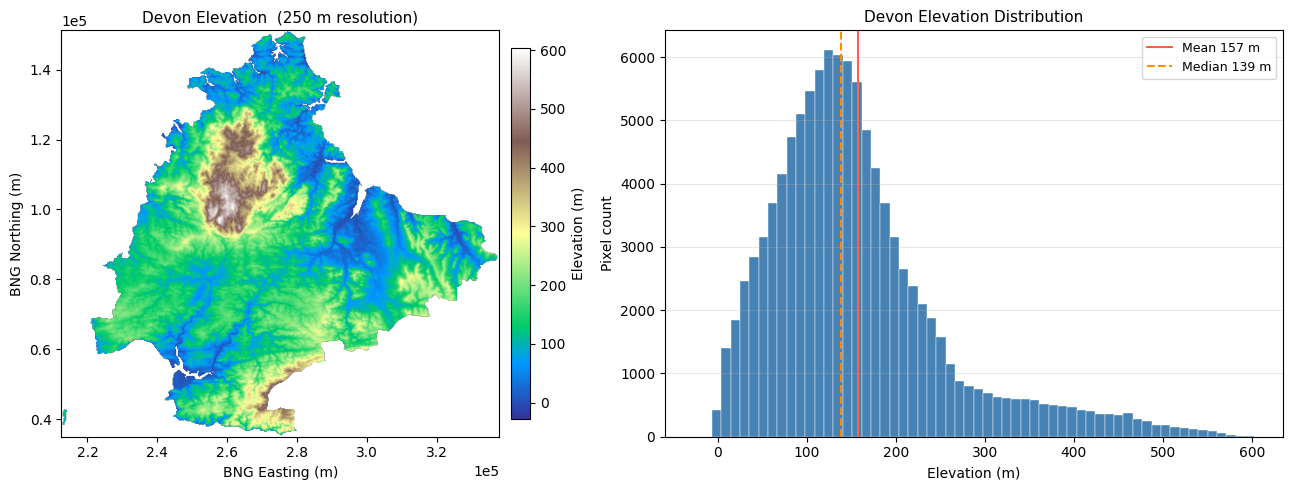

In [6]:
# ── Static elevation map ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left panel: elevation raster
ax = axes[0]
im = ax.imshow(
    devon_elev.values[::-1],   # flip so north is up
    cmap=ELEV_CMAP,
    origin='lower',
    extent=[
        float(devon_elev.x[0]),  float(devon_elev.x[-1]),
        float(devon_elev.y[0]),  float(devon_elev.y[-1]),
    ],
    aspect='equal',
)
cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label('Elevation (m)')
ax.set_xlabel('BNG Easting (m)')
ax.set_ylabel('BNG Northing (m)')
ax.set_title(f'Devon Elevation  ({RES_M} m resolution)', fontsize=11)
ax.ticklabel_format(style='sci', axis='both', scilimits=(5, 5))

# Right panel: elevation histogram
ax2 = axes[1]
valid_vals = devon_elev.values[np.isfinite(devon_elev.values)].ravel()
ax2.hist(valid_vals, bins=60, color='steelblue', edgecolor='white', linewidth=0.3)
ax2.axvline(float(devon_elev.mean()), color='tomato', lw=1.5,
            label=f'Mean {float(devon_elev.mean()):.0f} m')
ax2.axvline(float(np.nanmedian(valid_vals)), color='darkorange', lw=1.5, linestyle='--',
            label=f'Median {float(np.nanmedian(valid_vals)):.0f} m')
ax2.set_xlabel('Elevation (m)')
ax2.set_ylabel('Pixel count')
ax2.set_title('Devon Elevation Distribution', fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


## 3 — Interactive Devon elevation map

The map below renders the Devon elevation raster as a semi-transparent
overlay on a CartoDB positron basemap.  The raster is first warped from
BNG to WGS-84 space so that it aligns correctly with the vector county
boundary.  **Use the layer control** (top-right) to toggle layers.



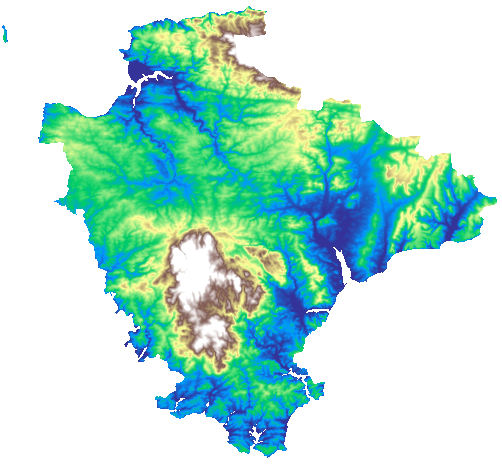

In [7]:
finite_elev = devon_elev.values[np.isfinite(devon_elev.values)]
vmin_e = float(np.percentile(finite_elev, 2))
vmax_e = float(np.percentile(finite_elev, 98))

m = folium.Map(
    location=DEVON_CENTRE,
    zoom_start=9,
    tiles=TILES,
    scroll_wheel_zoom=False,
    height=620,
)

# Devon boundary
folium.GeoJson(
    devon_gdf.__geo_interface__,
    name='Devon boundary',
    style_function=lambda _: {
        'color':       '#2c6e8a',
        'fillColor':   'none',
        'fillOpacity': 0,
        'weight':      2.5,
    },
).add_to(m)

# Elevation raster overlay
_make_raster_overlay(
    devon_elev,
    cmap=ELEV_CMAP,
    vmin=vmin_e,
    vmax=vmax_e,
    alpha=0.70,
    label='Elevation (m)',
).add_to(m)

# Colour-bar legend
m.get_root().html.add_child(
    folium.Element(_legend_html(vmin_e, vmax_e, ELEV_CMAP, 'Elevation', 'm'))
)

folium.LayerControl(collapsed=False).add_to(m)
m


## 4 — Slope analysis — Devon county

`get_slope_for_polygon` computes terrain slope using **Horn's (1981)
3 × 3 neighbourhood method** — identical to the ArcGIS Spatial Analyst
*Slope* tool (planar method).  It accepts the same polygon and DEM
inputs as `get_topography_for_polygon` and returns an
`xarray.DataArray` with the same BNG grid.

Three output units are supported:

| `output=`      | Interpretation |
|----------------|----------------|
| `"degrees"`      | Angle from horizontal, 0–90° |
| `"percent_rise"` | Rise/run × 100, 0–∞ |
| `"radians"`      | Angle from horizontal in radians |

> **Algorithm note:** one-cell buffer expansion is applied before the
> kernel so that every in-polygon border cell has valid neighbours; the
> buffer is removed before returning.


In [8]:
print(f'Computing slope for Devon county  (res={RES_M} m) …')  # ~2 s at 250 m
t0 = _time.perf_counter()

devon_slope_deg = get_slope_for_polygon(
    devon_poly,
    dem_path=DEM_PATH,
    res=RES_M,
    output='degrees',
)

devon_slope_pct = get_slope_for_polygon(
    devon_poly,
    dem_path=DEM_PATH,
    res=RES_M,
    output='percent_rise',
)

elapsed = _time.perf_counter() - t0
print(f'Done in {elapsed:.1f} s\n')
print(devon_slope_deg)
print()

finite_slope = devon_slope_deg.values[np.isfinite(devon_slope_deg.values)]
print(f'Min slope  : {finite_slope.min():.2f}°')
print(f'Max slope  : {finite_slope.max():.2f}°')
print(f'Mean slope : {finite_slope.mean():.2f}°')
print(f'Median slope : {np.median(finite_slope):.2f}°')
print(f'Pixels >15° : {(finite_slope > 15).sum():,}  '
      f'({100*(finite_slope > 15).mean():.1f}% of in-polygon pixels)')


Computing slope for Devon county  (res=250 m) …
2026-03-23 16:58:44,779 - eoflow.topography - INFO - get_slope_for_polygon
2026-03-23 16:58:44,780 - eoflow.topography - INFO -   Polygon BNG bounds : 212711, 35070 → 337581, 151206
2026-03-23 16:58:44,781 - eoflow.topography - INFO -   Buffered extent    : x=[212250, 338250]  y=[34750, 151750]  res=250 m
2026-03-23 16:58:44,781 - eoflow.topography - INFO -   Slope output units : degrees
2026-03-23 16:58:44,780 - eoflow.topography - INFO -   Polygon BNG bounds : 212711, 35070 → 337581, 151206
2026-03-23 16:58:44,781 - eoflow.topography - INFO -   Buffered extent    : x=[212250, 338250]  y=[34750, 151750]  res=250 m
2026-03-23 16:58:44,781 - eoflow.topography - INFO -   Slope output units : degrees
2026-03-23 16:58:46,915 - eoflow.topography - INFO - Assembled slope DataArray: grid 466 (y) × 502 (x).
2026-03-23 16:58:46,991 - eoflow.topography - INFO - get_slope_for_polygon
2026-03-23 16:58:46,992 - eoflow.topography - INFO -   Polygon BNG

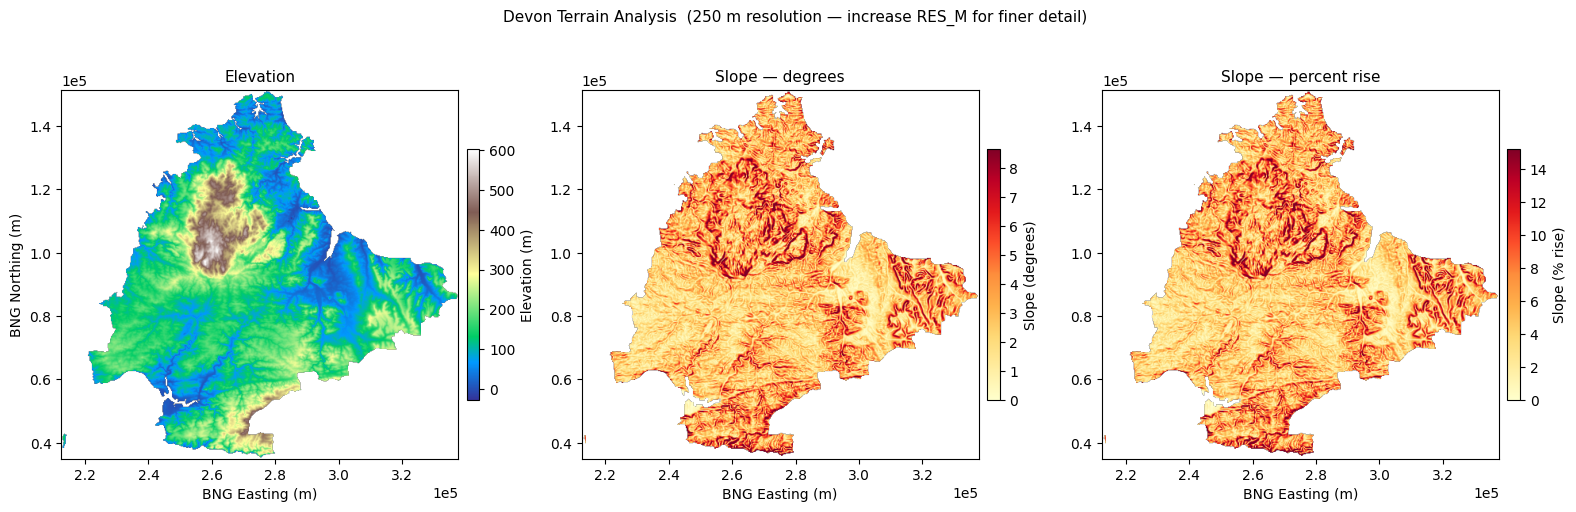

In [9]:
# ── Static slope maps — degrees vs percent rise ────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

extent_args = dict(
    origin='lower',
    aspect='equal',
    extent=[
        float(devon_slope_deg.x[0]),  float(devon_slope_deg.x[-1]),
        float(devon_slope_deg.y[0]),  float(devon_slope_deg.y[-1]),
    ],
)

# Panel 1 — Elevation
ax = axes[0]
im0 = ax.imshow(devon_elev.values[::-1],      cmap=ELEV_CMAP,  **extent_args)
fig.colorbar(im0, ax=ax, fraction=0.03, pad=0.02).set_label('Elevation (m)')
ax.set_title('Elevation', fontsize=11)
ax.set_xlabel('BNG Easting (m)')
ax.set_ylabel('BNG Northing (m)')
ax.ticklabel_format(style='sci', axis='both', scilimits=(5, 5))

# Panel 2 — Slope (degrees)
ax = axes[1]
clip_deg = np.nanpercentile(finite_slope, 98)
im1 = ax.imshow(devon_slope_deg.values[::-1], cmap=SLOPE_CMAP,
                vmin=0, vmax=clip_deg, **extent_args)
fig.colorbar(im1, ax=ax, fraction=0.03, pad=0.02).set_label('Slope (degrees)')
ax.set_title('Slope — degrees', fontsize=11)
ax.set_xlabel('BNG Easting (m)')
ax.ticklabel_format(style='sci', axis='both', scilimits=(5, 5))

# Panel 3 — Slope (% rise)
ax = axes[2]
finite_pct = devon_slope_pct.values[np.isfinite(devon_slope_pct.values)]
clip_pct   = np.nanpercentile(finite_pct, 98)
im2 = ax.imshow(devon_slope_pct.values[::-1], cmap=SLOPE_CMAP,
                vmin=0, vmax=clip_pct, **extent_args)
fig.colorbar(im2, ax=ax, fraction=0.03, pad=0.02).set_label('Slope (% rise)')
ax.set_title('Slope — percent rise', fontsize=11)
ax.set_xlabel('BNG Easting (m)')
ax.ticklabel_format(style='sci', axis='both', scilimits=(5, 5))

plt.suptitle(f'Devon Terrain Analysis  ({RES_M} m resolution — increase RES_M for finer detail)', fontsize=11, y=1.01)
plt.tight_layout()
plt.show()



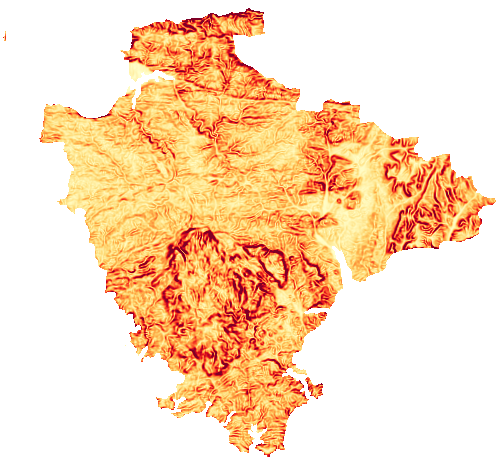

In [10]:
# ── Interactive Devon slope map (degrees) ─────────────────────────────────
vmin_s = 0.0
vmax_s = float(np.nanpercentile(finite_slope, 98))

m2 = folium.Map(
    location=DEVON_CENTRE,
    zoom_start=9,
    tiles=TILES,
    scroll_wheel_zoom=False,
    height=620,
)

folium.GeoJson(
    devon_gdf.__geo_interface__,
    name='Devon boundary',
    style_function=lambda _: {
        'color':       '#2c6e8a',
        'fillColor':   'none',
        'fillOpacity': 0,
        'weight':      2.5,
    },
).add_to(m2)

_make_raster_overlay(
    devon_slope_deg,
    cmap=SLOPE_CMAP,
    vmin=vmin_s,
    vmax=vmax_s,
    alpha=0.70,
    label='Slope (degrees)',
).add_to(m2)

m2.get_root().html.add_child(
    folium.Element(_legend_html(vmin_s, vmax_s, SLOPE_CMAP, 'Slope', '°'))
)

folium.LayerControl(collapsed=False).add_to(m2)
m2


## 6 — Aspect (slope direction) — Devon county

`get_aspect_for_polygon` computes the **compass bearing of the steepest
uphill direction** for each grid cell — i.e. which way the terrain faces.

Aspect is measured **clockwise from North**:
- 0° / 360° = North
- 90° = East
- 180° = South
- 270° = West

It uses the same Horn (1981) 3 × 3 neighbourhood as the slope calculation;
flat cells (zero gradient) are returned as `NaN`.

The `'twilight'` colourmap is used because it is **perceptually uniform and
cyclic** — North (0°) and North (360°) map to the same colour with no sharp
discontinuity.


In [11]:
print(f'Computing aspect for Devon county  (res={RES_M} m) …')
t0 = _time.perf_counter()

devon_aspect = get_aspect_for_polygon(
    devon_poly,
    dem_path=DEM_PATH,
    res=RES_M,
    output='degrees',
)

elapsed = _time.perf_counter() - t0
print(f'Done in {elapsed:.1f} s\n')
print(devon_aspect)
print()

finite_asp = devon_aspect.values[np.isfinite(devon_aspect.values)]
print(f'Non-flat pixels : {finite_asp.size:,}')

# Circular mean (ordinary mean is meaningless for angular data because
# 1° and 359° average to 180°, not 0°).
asp_rad_dev   = np.deg2rad(finite_asp)
circ_mean_dev = (
    np.degrees(
        np.arctan2(np.sin(asp_rad_dev).mean(), np.cos(asp_rad_dev).mean())
    ) % 360
)
print(f'Circular mean aspect : {circ_mean_dev:.1f}°')


Computing aspect for Devon county  (res=250 m) …
2026-03-23 16:58:53,120 - eoflow.topography - INFO - get_aspect_for_polygon
2026-03-23 16:58:53,121 - eoflow.topography - INFO -   Polygon BNG bounds : 212711, 35070 → 337581, 151206
2026-03-23 16:58:53,122 - eoflow.topography - INFO -   Buffered extent    : x=[212250, 338250]  y=[34750, 151750]  res=250 m
2026-03-23 16:58:53,122 - eoflow.topography - INFO -   Aspect output units : degrees
2026-03-23 16:58:53,121 - eoflow.topography - INFO -   Polygon BNG bounds : 212711, 35070 → 337581, 151206
2026-03-23 16:58:53,122 - eoflow.topography - INFO -   Buffered extent    : x=[212250, 338250]  y=[34750, 151750]  res=250 m
2026-03-23 16:58:53,122 - eoflow.topography - INFO -   Aspect output units : degrees
2026-03-23 16:58:55,014 - eoflow.topography - INFO - Assembled aspect DataArray: grid 466 (y) × 502 (x).
Done in 2.0 s

<xarray.DataArray 'aspect' (y: 466, x: 502)> Size: 936kB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, na

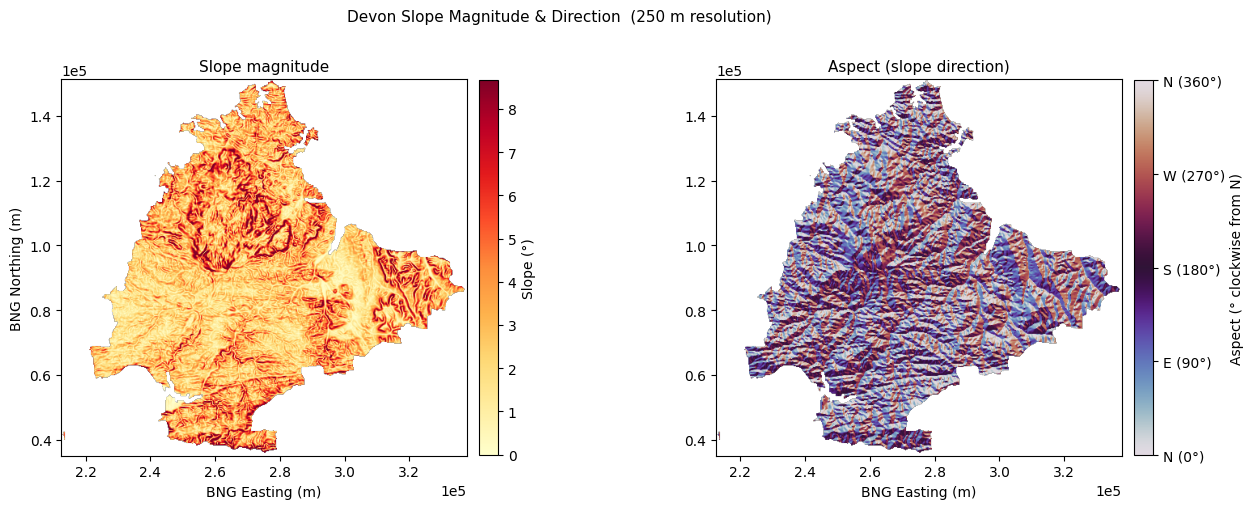

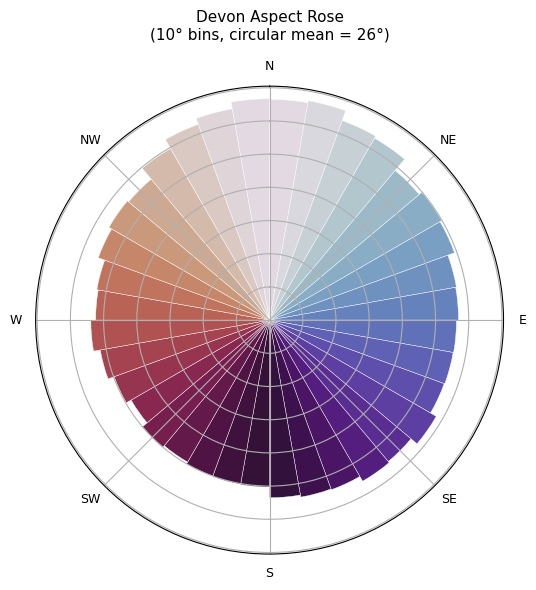

In [12]:
# ── Static maps: slope magnitude (left) + aspect direction (right) ────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

extent_args_asp = dict(
    origin='lower',
    aspect='equal',
    extent=[
        float(devon_aspect.x[0]),  float(devon_aspect.x[-1]),
        float(devon_aspect.y[0]),  float(devon_aspect.y[-1]),
    ],
)

# Left panel — slope magnitude
ax = axes[0]
im0 = ax.imshow(
    devon_slope_deg.values[::-1], cmap=SLOPE_CMAP,
    vmin=0, vmax=clip_deg, **extent_args_asp,
)
fig.colorbar(im0, ax=ax, fraction=0.03, pad=0.02).set_label('Slope (°)')
ax.set_title('Slope magnitude', fontsize=11)
ax.set_xlabel('BNG Easting (m)')
ax.set_ylabel('BNG Northing (m)')
ax.ticklabel_format(style='sci', axis='both', scilimits=(5, 5))

# Right panel — aspect
ax = axes[1]
im1 = ax.imshow(
    devon_aspect.values[::-1], cmap=ASPECT_CMAP,
    vmin=0, vmax=360, **extent_args_asp,
)
cb = fig.colorbar(im1, ax=ax, fraction=0.03, pad=0.02)
cb.set_label('Aspect (° clockwise from N)')
cb.set_ticks([0, 90, 180, 270, 360])
cb.set_ticklabels(['N (0°)', 'E (90°)', 'S (180°)', 'W (270°)', 'N (360°)'])
ax.set_title('Aspect (slope direction)', fontsize=11)
ax.set_xlabel('BNG Easting (m)')
ax.ticklabel_format(style='sci', axis='both', scilimits=(5, 5))

plt.suptitle(
    f'Devon Slope Magnitude & Direction  ({RES_M} m resolution)',
    fontsize=11, y=1.01,
)
plt.tight_layout()
plt.show()

# ── Aspect rose (polar histogram) ─────────────────────────────────────────
fig_rose, ax_rose = plt.subplots(
    figsize=(6, 6), subplot_kw=dict(projection='polar')
)

n_bins      = 36   # 10° per bin
bin_edges   = np.linspace(0, 2 * np.pi, n_bins + 1)
counts_dev, _ = np.histogram(np.deg2rad(finite_asp), bins=bin_edges)
bin_centres = (bin_edges[:-1] + bin_edges[1:]) / 2
bar_width   = 2 * np.pi / n_bins
bin_colours = plt.get_cmap(ASPECT_CMAP)(np.linspace(0, 1, n_bins))

ax_rose.bar(
    bin_centres, counts_dev,
    width=bar_width, bottom=0,
    color=bin_colours, edgecolor='white', linewidth=0.3, align='center',
)
ax_rose.set_theta_direction(-1)        # clockwise
ax_rose.set_theta_zero_location('N')   # North at top
ax_rose.set_xticks(np.deg2rad([0, 45, 90, 135, 180, 225, 270, 315]))
ax_rose.set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'], fontsize=9)
ax_rose.set_yticklabels([])
ax_rose.set_title(
    f'Devon Aspect Rose\n(10° bins, circular mean = {circ_mean_dev:.0f}°)',
    fontsize=11, pad=15,
)
plt.tight_layout()
plt.show()



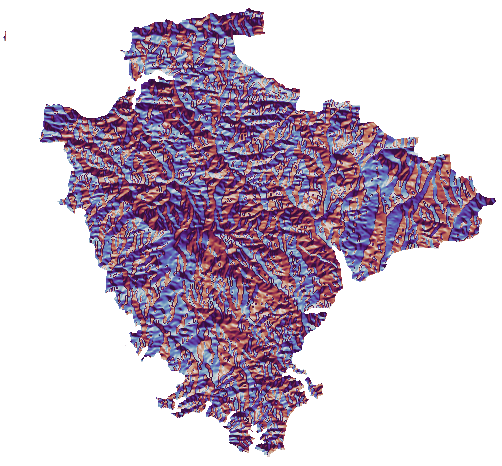

In [13]:
# ── Interactive Devon aspect map ──────────────────────────────────────────
m_asp = folium.Map(
    location=DEVON_CENTRE,
    zoom_start=9,
    tiles=TILES,
    scroll_wheel_zoom=False,
    height=620,
)

folium.GeoJson(
    devon_gdf.__geo_interface__,
    name='Devon boundary',
    style_function=lambda _: {
        'color':       '#2c6e8a',
        'fillColor':   'none',
        'fillOpacity': 0,
        'weight':      2.5,
    },
).add_to(m_asp)

_make_raster_overlay(
    devon_aspect,
    cmap=ASPECT_CMAP,
    vmin=0,
    vmax=360,
    alpha=0.70,
    label='Aspect (° from N)',
).add_to(m_asp)

m_asp.get_root().html.add_child(
    folium.Element(_legend_html(0, 360, ASPECT_CMAP, 'Aspect', '°'))
)

folium.LayerControl(collapsed=False).add_to(m_asp)
m_asp


## 7 — Per-catchment topography

For each of the 10 sample sites with a delineated catchment polygon we
call `get_topography_for_polygon`, `get_slope_for_polygon`, and
`get_aspect_for_polygon` at the default **50 m** resolution.  The DEM is
already on disk so there is no network traffic.

> **Tip:** very small catchments (< 1 km²) may contain only a handful of
> 50 m pixels.  Use `RES_CATCHMENT=25` for finer coverage at the cost of
> longer compute time.


In [14]:
catchment_records = []

for sample in ds:
    if not sample.has_catchment:
        continue

    poly = sample.catchment   # Shapely Polygon in WGS 84

    try:
        t0 = _time.perf_counter()

        elev_da  = get_topography_for_polygon(poly, dem_path=DEM_PATH, res=RES_CATCHMENT)
        slope_da = get_slope_for_polygon(poly,      dem_path=DEM_PATH, res=RES_CATCHMENT)

        elapsed = _time.perf_counter() - t0

        elev_vals  = elev_da.values[np.isfinite(elev_da.values)]
        slope_vals = slope_da.values[np.isfinite(slope_da.values)]

        catchment_records.append({
            'notation':        sample.notation,
            'site_name':       sample.site_name,
            'area_km2':        round(sample.catchment_area_km2() or 0.0, 3),
            'n_pixels':        len(elev_vals),
            'min_elev_m':      round(float(elev_vals.min()),  1) if elev_vals.size else float('nan'),
            'max_elev_m':      round(float(elev_vals.max()),  1) if elev_vals.size else float('nan'),
            'mean_elev_m':     round(float(elev_vals.mean()), 1) if elev_vals.size else float('nan'),
            'mean_slope_deg':  round(float(slope_vals.mean()), 2) if slope_vals.size else float('nan'),
            'max_slope_deg':   round(float(slope_vals.max()),  2) if slope_vals.size else float('nan'),
            'pct_steep':       round(100.0 * (slope_vals > 15).mean(), 1) if slope_vals.size else float('nan'),
        })
        print(
            f'  [{sample.notation}]  '
            f'elev {float(elev_vals.min() if elev_vals.size else float("nan")):.0f}–'
            f'{float(elev_vals.max() if elev_vals.size else float("nan")):.0f} m  '
            f'slope_mean={float(slope_vals.mean() if slope_vals.size else float("nan")):.1f}°  '
            f'pixels={len(elev_vals)}  '
            f'({elapsed:.1f} s)'
        )

    except Exception as exc:
        print(f'  [{sample.notation}]  ERROR: {exc}')

catch_df = (
    pd.DataFrame(catchment_records)
    .sort_values('mean_elev_m', ascending=False)
    .reset_index(drop=True)
)
print(f'\nProcessed {len(catch_df)} catchment(s).')


2026-03-23 17:00:13,605 - eoflow.topography - INFO - get_topography_for_polygon
2026-03-23 17:00:13,605 - eoflow.topography - INFO -   Polygon BNG bounds : 308748, 87344 → 310299, 88702
2026-03-23 17:00:13,606 - eoflow.topography - INFO -   Extraction extent  : x=[308700, 310350]  y=[87300, 88800]  res=50 m
2026-03-23 17:00:13,615 - eoflow.topography - INFO -   Polygon covers 332 / 990 pixel(s) (33.5%) on the BNG grid.
2026-03-23 17:00:13,617 - eoflow.topography - INFO - Assembled elevation DataArray: grid 30 (y) × 33 (x).
2026-03-23 17:00:13,605 - eoflow.topography - INFO -   Polygon BNG bounds : 308748, 87344 → 310299, 88702
2026-03-23 17:00:13,606 - eoflow.topography - INFO -   Extraction extent  : x=[308700, 310350]  y=[87300, 88800]  res=50 m
2026-03-23 17:00:13,615 - eoflow.topography - INFO -   Polygon covers 332 / 990 pixel(s) (33.5%) on the BNG grid.
2026-03-23 17:00:13,617 - eoflow.topography - INFO - Assembled elevation DataArray: grid 30 (y) × 33 (x).
2026-03-23 17:00:13,66

In [15]:
# ── Catchment summary table ────────────────────────────────────────────────
catch_df


,notation,site_name,area_km2,n_pixels,min_elev_m,max_elev_m,mean_elev_m,mean_slope_deg,max_slope_deg,pct_steep
0,SW-70720104,RIVER DART AT TOTNES WEIR,281.128,112745,3.3,601.0,297.7,6.71,35.14,4.8
1,SW-70631918,KENNICK STREAM AT TOTTIFORD RESERVOIR SURFACE,4.931,1984,238.0,353.0,282.7,6.21,18.42,2.7
2,SW-70620154,RIVER TEIGN AT PRESTON,106.654,42793,-41.0,498.1,226.0,7.19,36.58,7.5
3,SW-70826005,RIVER AVON AT HATCH,102.955,41290,4.0,512.8,202.9,6.66,29.70,4.2
4,SW-70540224,RIVER EXE AT THORVERTON GAUGING STATION,271.882,109038,26.5,298.9,171.5,6.63,35.08,5.0
5,SW-70540110,RIVER EXE AT TREWS WEIR EXETER,836.913,335624,1.7,300.7,138.5,5.44,35.08,2.4
6,SW-70420116,RIVER OTTER AT DOTTON MILL,0.821,332,15.2,197.2,108.2,9.27,21.46,9.6
7,SW-72920121,RIVER TORRIDGE AT BEAM BRIDGE,3.890,1561,7.6,135.2,91.9,5.65,30.29,4.1
8,SW-70920104,RIVER ERME AT SEQUER'S BRIDGE,1.234,490,3.9,143.8,60.5,7.60,18.21,1.6
9,SW-73020127,RIVER TAW AT CHAPELTON FOOTBRIDGE,1.071,426,8.2,98.2,42.9,3.47,9.65,0.0


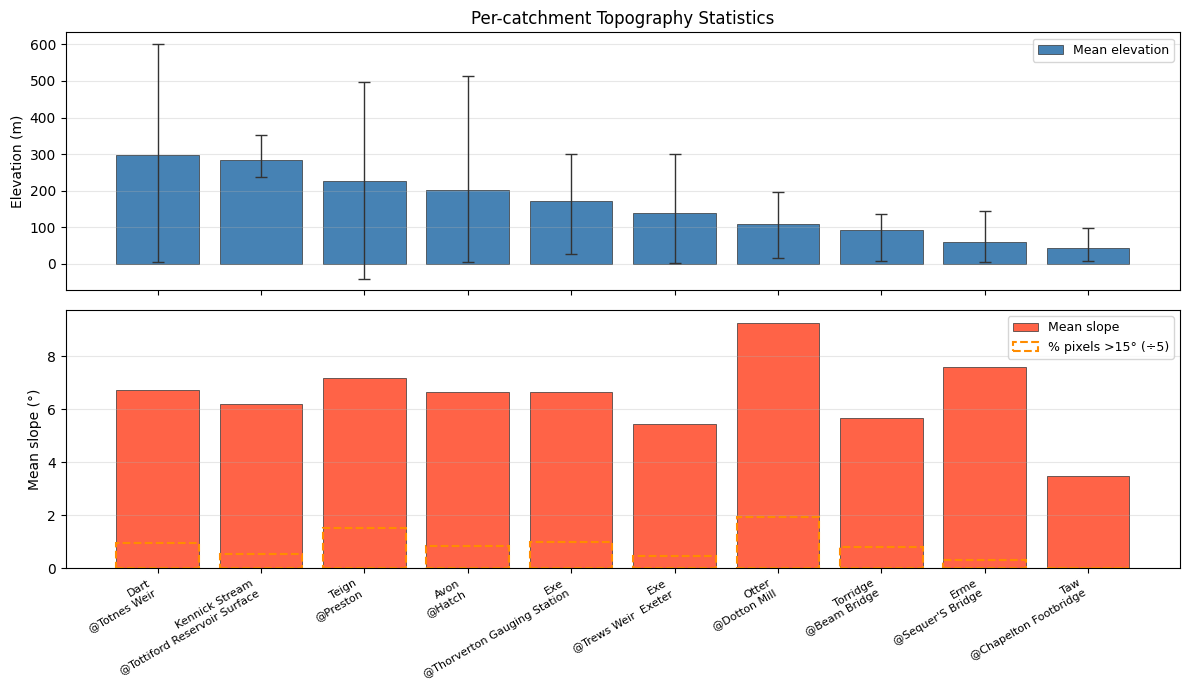

In [20]:
# ── Bar chart: mean elevation and mean slope by catchment ──────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

labels = [
    r['site_name'].replace('RIVER ', '').replace(' AT ', '\n@').title()
    for r in catchment_records
]
sorted_df = catch_df.copy()
sorted_labels = [
    r['site_name'].replace('RIVER ', '').replace(' AT ', '\n@').title()
    for _, r in sorted_df.iterrows()
]

x = np.arange(len(sorted_df))

# Elevation panel
bars1 = ax1.bar(x, sorted_df['mean_elev_m'], color='steelblue',
                edgecolor='#333', linewidth=0.5, label='Mean elevation')
ax1.errorbar(
    x,
    sorted_df['mean_elev_m'],
    yerr=[
        sorted_df['mean_elev_m'] - sorted_df['min_elev_m'],
        sorted_df['max_elev_m'] - sorted_df['mean_elev_m'],
    ],
    fmt='none', ecolor='#333', capsize=4, lw=1,
)
ax1.set_ylabel('Elevation (m)')
ax1.set_title('Per-catchment Topography Statistics', fontsize=12)
ax1.grid(axis='y', alpha=0.3)
ax1.legend(fontsize=9)

# Slope panel
bars2 = ax2.bar(x, sorted_df['mean_slope_deg'], color='tomato',
                edgecolor='#333', linewidth=0.5, label='Mean slope')
ax2.bar(x, sorted_df['pct_steep'] / 5,  # scale % steep to same axis
        color='none', edgecolor='darkorange', linewidth=1.5,
        linestyle='--', label='% pixels >15° (÷5)')
ax2.set_ylabel('Mean slope (°)')
ax2.set_xticks(x)
ax2.set_xticklabels(sorted_labels, rotation=30, ha='right', fontsize=8)
ax2.grid(axis='y', alpha=0.3)
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()


## 8 — Devon overview map — elevation + catchments

Combined interactive map showing:

1. **Devon boundary** — county outline (blue).
2. **Elevation raster** — Copernicus DEM at 100 m (terrain colourmap).
3. **Slope raster** — Horn (1981) slope in degrees at 100 m (YlOrRd).
4. **Catchment polygons** — 10 water-quality sampling catchments, coloured
   by mean elevation with tooltips showing site metadata.

Use the **layer control** (top-right) to toggle any layer on or off.


In [21]:
# ── Colour catchments by mean elevation ───────────────────────────────────
# Build a GeoDataFrame with catchment geometries + stats
catch_rows = []
catch_by_notation = {r['notation']: r for r in catchment_records}

for sample in ds:
    if not sample.has_catchment or sample.notation not in catch_by_notation:
        continue
    rec = catch_by_notation[sample.notation]
    catch_rows.append({
        'notation':       sample.notation,
        'site_name':      sample.site_name,
        'area_km2':       rec['area_km2'],
        'mean_elev_m':    rec['mean_elev_m'],
        'mean_slope_deg': rec['mean_slope_deg'],
        'pct_steep':      rec['pct_steep'],
        'geometry':       sample.catchment,
    })

catch_gdf = gpd.GeoDataFrame(catch_rows, crs='EPSG:4326')

# Elevation → colour for polygon fill
elev_vals_c = catch_gdf['mean_elev_m'].values.astype(float)
elev_norm   = plt.Normalize(vmin=elev_vals_c.min(), vmax=elev_vals_c.max())
cmap_c      = plt.get_cmap('RdYlGn_r')

def _elev_colour(e):
    return mcolors.to_hex(cmap_c(elev_norm(e)))

print(f'Catchment GeoDataFrame: {len(catch_gdf)} rows')
catch_gdf[['notation', 'site_name', 'mean_elev_m', 'mean_slope_deg', 'pct_steep']]


Catchment GeoDataFrame: 10 rows


,notation,site_name,mean_elev_m,mean_slope_deg,pct_steep
0,SW-70420116,RIVER OTTER AT DOTTON MILL,108.2,9.27,9.6
1,SW-70540110,RIVER EXE AT TREWS WEIR EXETER,138.5,5.44,2.4
2,SW-70540224,RIVER EXE AT THORVERTON GAUGING STATION,171.5,6.63,5.0
3,SW-70620154,RIVER TEIGN AT PRESTON,226.0,7.19,7.5
4,SW-70631918,KENNICK STREAM AT TOTTIFORD RESERVOIR SURFACE,282.7,6.21,2.7
5,SW-70720104,RIVER DART AT TOTNES WEIR,297.7,6.71,4.8
6,SW-70826005,RIVER AVON AT HATCH,202.9,6.66,4.2
7,SW-70920104,RIVER ERME AT SEQUER'S BRIDGE,60.5,7.60,1.6
8,SW-72920121,RIVER TORRIDGE AT BEAM BRIDGE,91.9,5.65,4.1
9,SW-73020127,RIVER TAW AT CHAPELTON FOOTBRIDGE,42.9,3.47,0.0



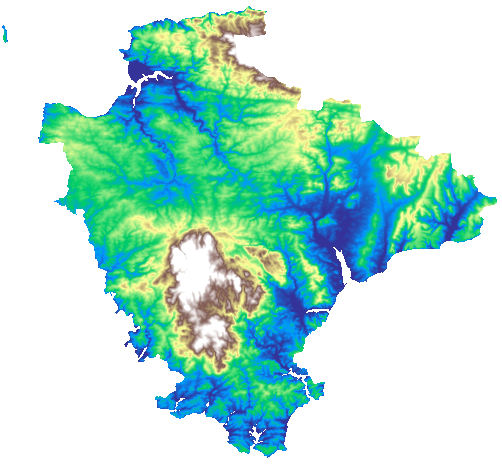
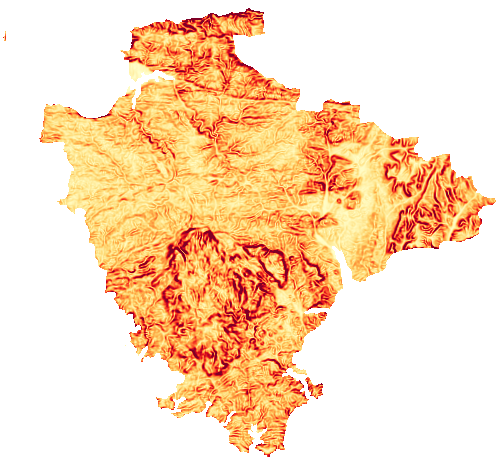

In [22]:
# ── Build overview map ────────────────────────────────────────────────────
m3 = folium.Map(
    location=DEVON_CENTRE,
    zoom_start=9,
    tiles=TILES,
    scroll_wheel_zoom=False,
    height=650,
)

# Layer 1: Devon county boundary
folium.GeoJson(
    devon_gdf.__geo_interface__,
    name='Devon boundary',
    style_function=lambda _: {
        'color':       '#2c6e8a',
        'fillColor':   'none',
        'fillOpacity': 0,
        'weight':      2.5,
    },
).add_to(m3)

# Layer 2: Elevation raster
_make_raster_overlay(
    devon_elev,
    cmap=ELEV_CMAP,
    vmin=vmin_e,
    vmax=vmax_e,
    alpha=0.65,
    label='Elevation (m)',
).add_to(m3)

# Layer 3: Slope raster
_make_raster_overlay(
    devon_slope_deg,
    cmap=SLOPE_CMAP,
    vmin=0,
    vmax=vmax_s,
    alpha=0.55,
    label='Slope (degrees)',
).add_to(m3)

# Layer 4: Catchment polygons, coloured by mean elevation
def _style_fn(feature):
    e = feature['properties']['mean_elev_m']
    return {
        'fillColor':   _elev_colour(e),
        'color':       '#333333',
        'weight':      1.5,
        'fillOpacity': 0.55,
    }

folium.GeoJson(
    catch_gdf.__geo_interface__,
    name='Catchments (mean elevation)',
    style_function=_style_fn,
    tooltip=folium.GeoJsonTooltip(
        fields=['site_name', 'area_km2', 'mean_elev_m', 'mean_slope_deg', 'pct_steep'],
        aliases=['Site', 'Area (km²)', 'Mean elev (m)', 'Mean slope (°)', '% steep (>15°)'],
        localize=True,
    ),
).add_to(m3)

# Elevation legend
m3.get_root().html.add_child(
    folium.Element(_legend_html(vmin_e, vmax_e, ELEV_CMAP, 'Elevation', 'm'))
)

folium.LayerControl(collapsed=False).add_to(m3)
m3


## 9 — Dartmoor close-up: elevation, slope & aspect

Dartmoor — the large upland plateau in central Devon — shows clearly in
the county-wide maps.  Here we zoom into the **River Dart at Totnes Weir**
catchment (the largest in the dataset, ~281 km²) to compare elevation,
slope magnitude, and slope direction side by side at the default **50 m**
resolution.  The aspect rose (polar histogram) reveals which compass
directions dominate the catchment's terrain.


In [23]:
# Locate the Dart catchment sample
dart_sample = next(
    (s for s in ds if s.notation == 'SW-70720104' and s.has_catchment),
    None,
)

if dart_sample is None:
    print('Dart catchment not found — skipping.')
else:
    dart_poly = dart_sample.catchment

    print(f'Catchment : {dart_sample.site_name}')
    print(f'Area      : {dart_sample.catchment_area_km2():.1f} km²')

    t0 = _time.perf_counter()
    dart_elev   = get_topography_for_polygon(dart_poly, dem_path=DEM_PATH, res=RES_CATCHMENT)
    dart_slope  = get_slope_for_polygon(dart_poly,      dem_path=DEM_PATH, res=RES_CATCHMENT)
    dart_aspect = get_aspect_for_polygon(dart_poly,     dem_path=DEM_PATH, res=RES_CATCHMENT)
    elapsed = _time.perf_counter() - t0
    print(f'Grid      : {dart_elev.sizes["y"]} × {dart_elev.sizes["x"]}  ({elapsed:.1f} s)')

    dart_elev_vals   = dart_elev.values[np.isfinite(dart_elev.values)]
    dart_slope_vals  = dart_slope.values[np.isfinite(dart_slope.values)]
    dart_aspect_vals = dart_aspect.values[np.isfinite(dart_aspect.values)]

    print(f'Elev range : {dart_elev_vals.min():.0f} – {dart_elev_vals.max():.0f} m')
    print(f'Slope mean : {dart_slope_vals.mean():.1f}°  max: {dart_slope_vals.max():.1f}°')

    _asp_rad     = np.deg2rad(dart_aspect_vals)
    dart_asp_mean = (
        np.degrees(
            np.arctan2(np.sin(_asp_rad).mean(), np.cos(_asp_rad).mean())
        ) % 360
    )
    print(f'Circular mean aspect : {dart_asp_mean:.1f}°')


Catchment : RIVER DART AT TOTNES WEIR
Area      : 281.1 km²
2026-03-23 17:01:46,605 - eoflow.topography - INFO - get_topography_for_polygon
2026-03-23 17:01:46,606 - eoflow.topography - INFO -   Polygon BNG bounds : 256374, 59539 → 280072, 86111
2026-03-23 17:01:46,608 - eoflow.topography - INFO -   Extraction extent  : x=[256350, 280150]  y=[59500, 86200]  res=50 m


2026-03-23 17:01:50,507 - eoflow.topography - INFO -   Polygon covers 112745 / 254184 pixel(s) (44.4%) on the BNG grid.
2026-03-23 17:01:50,510 - eoflow.topography - INFO - Assembled elevation DataArray: grid 534 (y) × 476 (x).
2026-03-23 17:01:50,643 - eoflow.topography - INFO - get_slope_for_polygon
2026-03-23 17:01:50,644 - eoflow.topography - INFO -   Polygon BNG bounds : 256374, 59539 → 280072, 86111
2026-03-23 17:01:50,645 - eoflow.topography - INFO -   Buffered extent    : x=[256300, 280200]  y=[59450, 86250]  res=50 m
2026-03-23 17:01:50,645 - eoflow.topography - INFO -   Slope output units : degrees
2026-03-23 17:01:54,578 - eoflow.topography - INFO - Assembled slope DataArray: grid 534 (y) × 476 (x).
2026-03-23 17:01:54,650 - eoflow.topography - INFO - get_aspect_for_polygon
2026-03-23 17:01:54,650 - eoflow.topography - INFO -   Polygon BNG bounds : 256374, 59539 → 280072, 86111
2026-03-23 17:01:54,651 - eoflow.topography - INFO -   Buffered extent    : x=[256300, 280200]  y=

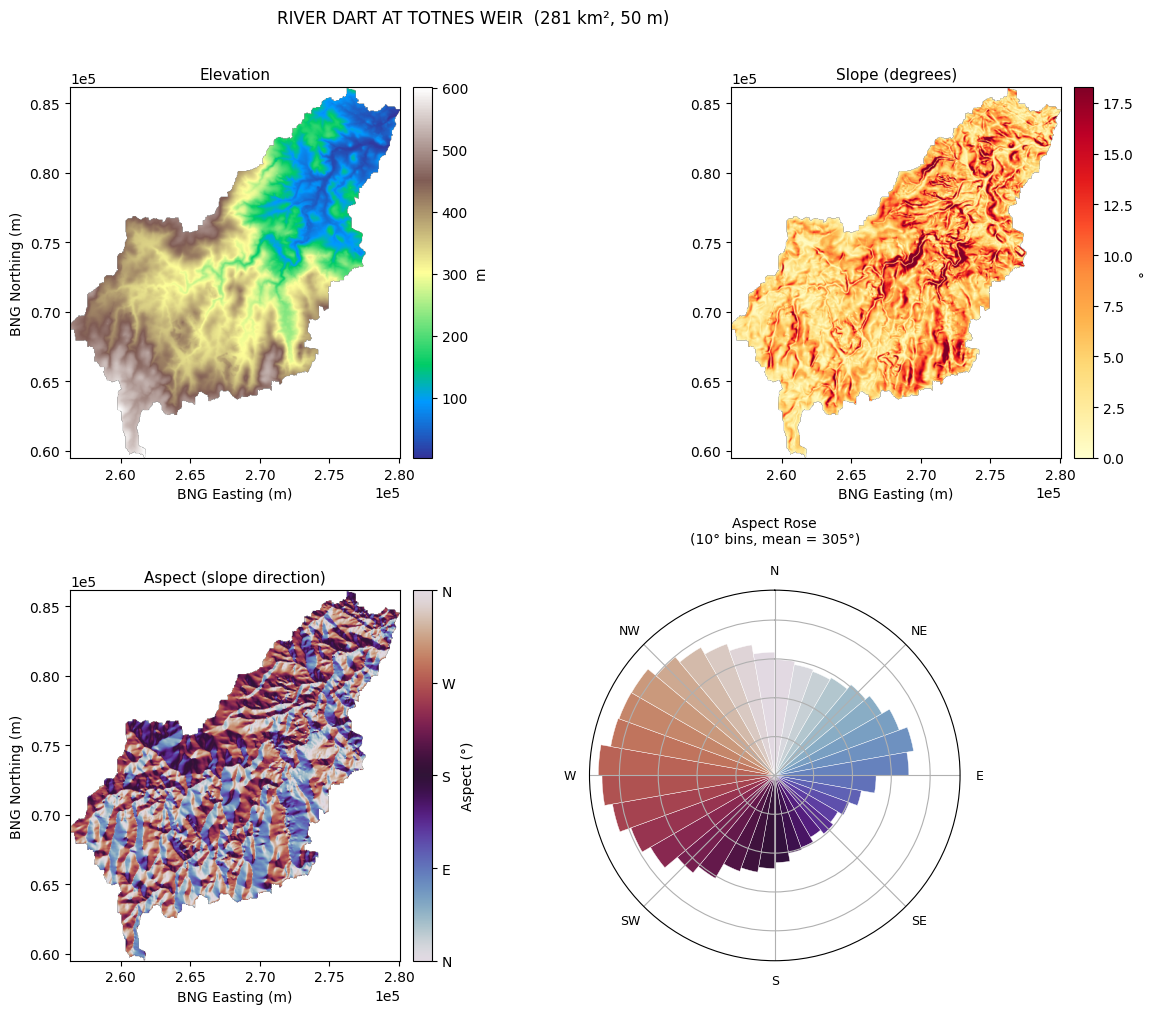

In [24]:
if dart_sample is not None:
    fig = plt.figure(figsize=(14, 10))

    ext = dict(
        origin='lower',
        aspect='equal',
        extent=[
            float(dart_elev.x[0]),  float(dart_elev.x[-1]),
            float(dart_elev.y[0]),  float(dart_elev.y[-1]),
        ],
    )

    # ── Panel [0,0]: Elevation ────────────────────────────────────────────
    ax00 = fig.add_subplot(2, 2, 1)
    im0  = ax00.imshow(dart_elev.values[::-1], cmap=ELEV_CMAP, **ext)
    fig.colorbar(im0, ax=ax00, fraction=0.04, pad=0.02).set_label('m')
    ax00.set_title('Elevation', fontsize=11)
    ax00.set_xlabel('BNG Easting (m)')
    ax00.set_ylabel('BNG Northing (m)')
    ax00.ticklabel_format(style='sci', axis='both', scilimits=(5, 5))

    # ── Panel [0,1]: Slope (degrees) ──────────────────────────────────────
    ax01   = fig.add_subplot(2, 2, 2)
    vmax_d = float(np.nanpercentile(dart_slope_vals, 98))
    im1    = ax01.imshow(dart_slope.values[::-1], cmap=SLOPE_CMAP,
                         vmin=0, vmax=vmax_d, **ext)
    fig.colorbar(im1, ax=ax01, fraction=0.04, pad=0.02).set_label('°')
    ax01.set_title('Slope (degrees)', fontsize=11)
    ax01.set_xlabel('BNG Easting (m)')
    ax01.ticklabel_format(style='sci', axis='both', scilimits=(5, 5))

    # ── Panel [1,0]: Aspect ───────────────────────────────────────────────
    ax10 = fig.add_subplot(2, 2, 3)
    im2  = ax10.imshow(dart_aspect.values[::-1], cmap=ASPECT_CMAP,
                       vmin=0, vmax=360, **ext)
    cb2  = fig.colorbar(im2, ax=ax10, fraction=0.04, pad=0.02)
    cb2.set_label('Aspect (°)')
    cb2.set_ticks([0, 90, 180, 270, 360])
    cb2.set_ticklabels(['N', 'E', 'S', 'W', 'N'])
    ax10.set_title('Aspect (slope direction)', fontsize=11)
    ax10.set_xlabel('BNG Easting (m)')
    ax10.set_ylabel('BNG Northing (m)')
    ax10.ticklabel_format(style='sci', axis='both', scilimits=(5, 5))

    # ── Panel [1,1]: Aspect rose (polar histogram) ────────────────────────
    ax11       = fig.add_subplot(2, 2, 4, projection='polar')
    n_bins_d   = 36
    bin_edges_d = np.linspace(0, 2 * np.pi, n_bins_d + 1)
    counts_d, _ = np.histogram(np.deg2rad(dart_aspect_vals), bins=bin_edges_d)
    bc_d        = (bin_edges_d[:-1] + bin_edges_d[1:]) / 2
    bw_d        = 2 * np.pi / n_bins_d

    ax11.bar(
        bc_d, counts_d,
        width=bw_d, bottom=0,
        color=plt.get_cmap(ASPECT_CMAP)(np.linspace(0, 1, n_bins_d)),
        edgecolor='white', linewidth=0.3, align='center',
    )
    ax11.set_theta_direction(-1)
    ax11.set_theta_zero_location('N')
    ax11.set_xticks(np.deg2rad([0, 45, 90, 135, 180, 225, 270, 315]))
    ax11.set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'], fontsize=9)
    ax11.set_yticklabels([])
    ax11.set_title(
        f'Aspect Rose\n(10° bins, mean = {dart_asp_mean:.0f}°)',
        fontsize=10, pad=15,
    )

    plt.suptitle(
        f'{dart_sample.site_name}  '
        f'({dart_sample.catchment_area_km2():.0f} km², {RES_CATCHMENT} m)',
        fontsize=12, y=1.01,
    )
    plt.tight_layout()
    plt.show()


## 10 — Summary

This notebook demonstrated the three public functions in
`eoflow.topography`:

### `get_topography_for_polygon`

```python
da = get_topography_for_polygon(
    polygon,           # Shapely geometry in WGS-84
    dem_path,          # Path to any-CRS GeoTIFF DEM
    res=50,            # Output resolution in BNG metres
)
# → xarray.DataArray  dims=(y, x)  units='m'  crs='EPSG:27700'
```

* Reprojects the source DEM (any CRS) to **EPSG:27700** via bilinear
  resampling.
* Masks all BNG grid cells whose centre lies **outside** the input polygon
  to `NaN`.
* Snaps the extraction window to the output resolution grid for
  consistent pixel alignment across repeated calls.

### `get_slope_for_polygon`

```python
da = get_slope_for_polygon(
    polygon,
    dem_path,
    res=50,
    output='degrees',  # or 'percent_rise' / 'radians'
)
# → xarray.DataArray  dims=(y, x)  units='degrees'  crs='EPSG:27700'
```

* Uses **Horn's (1981) 3 × 3 neighbourhood** algorithm — identical to
  ArcGIS Spatial Analyst `Slope` (planar method).
* Loads the DEM with a one-cell border buffer so every in-polygon cell
  has a complete neighbourhood; the buffer is cropped before output.
* Border cells, cells adjacent to no-data, and cells outside the polygon
  are `NaN`.

### `get_aspect_for_polygon`

```python
da = get_aspect_for_polygon(
    polygon,
    dem_path,
    res=50,
    output='degrees',  # or 'radians'
)
# → xarray.DataArray  dims=(y, x)  units='degrees'  crs='EPSG:27700'
#   attrs include  convention='clockwise from North'
```

* Derives the **compass bearing of the steepest uphill direction** from the
  same Horn (1981) partial derivatives used for slope magnitude.
* Bearing is measured **clockwise from North** (0° = N, 90° = E, 180° = S,
  270° = W).
* Flat cells (both partial derivatives zero) are `NaN`.
* Use a **cyclic colourmap** (e.g. `'twilight'`, `'hsv'`) for visualisation
  so that 0° and 360° (both North) render identically.
* Use the **circular mean** (`np.arctan2(sin.mean(), cos.mean())`) rather
  than an arithmetic mean when summarising aspect values statistically.
```

> **Coordinate reference system:** all three functions return data on a
> British National Grid (EPSG:27700) regular grid with `y` = northings and
> `x` = eastings, both in metres.
